# AutoRec: Autoencoders para Collaborative Filtering

Este experimento adiciona a **9a e 10a abordagens** ao comparativo de recomendacao do [movielens-recsys.ipynb](movielens-recsys.ipynb), que ja avaliou 8 paradigmas no MovieLens 100k:

| # | Abordagem | RMSE |
|---|-----------|------|
| 1 | Popularidade | 1.0171 |
| 2 | KNN User-based | 1.0194 |
| 3 | KNN Item-based | 1.0264 |
| 4 | SVD (MF) | 0.9352 |
| 5 | NCF (concat) | 0.9462 |
| 6 | LightGBM + FE | 0.9406 |
| 7 | BPR (pairwise) | 1.1138 |
| 8 | Two-Tower (dot) | **0.9297** |

O **AutoRec** (Sedhain et al., 2015 — *AutoRec: Autoencoders Meet Collaborative Filtering*) e um autoencoder classico treinado para **reconstruir vetores de rating parcialmente observados** usando apenas a loss sobre as entradas observadas (masked MSE). Ele pode ser construido de duas formas:

- **Item-based**: cada *item* `i` e representado pelo vetor de ratings que recebeu dos usuarios. O autoencoder comprime esse vetor esparso (dimensao = N_USERS) e o reconstroi — os espacos vazios sao preenchidos com a predicao.
- **User-based**: o espelho, cada *usuario* e representado pelo vetor de ratings que deu aos itens (dimensao = N_ITEMS).

A hipotese do experimento: em matrizes esparsas (~94%), o AutoRec **item-based** costuma superar SVD/ALS por aprender uma **representacao nao-linear comprimida** dos itens, em vez de fatorar com produto de baixo posto.

## Setup

In [1]:
import os, sys, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim

import mlflow

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


## 1. Dataset: MovieLens 100k

Carregamos o `u.data` diretamente (ja baixado pelo `surprise` em `~/.surprise_data/ml-100k/ml-100k`), sem depender da biblioteca.

Shape: (100000, 4)
Usuarios: 943, Itens: 1682
Sparsity: 0.9370
count    100000.000000
mean          3.529860
std           1.125674
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


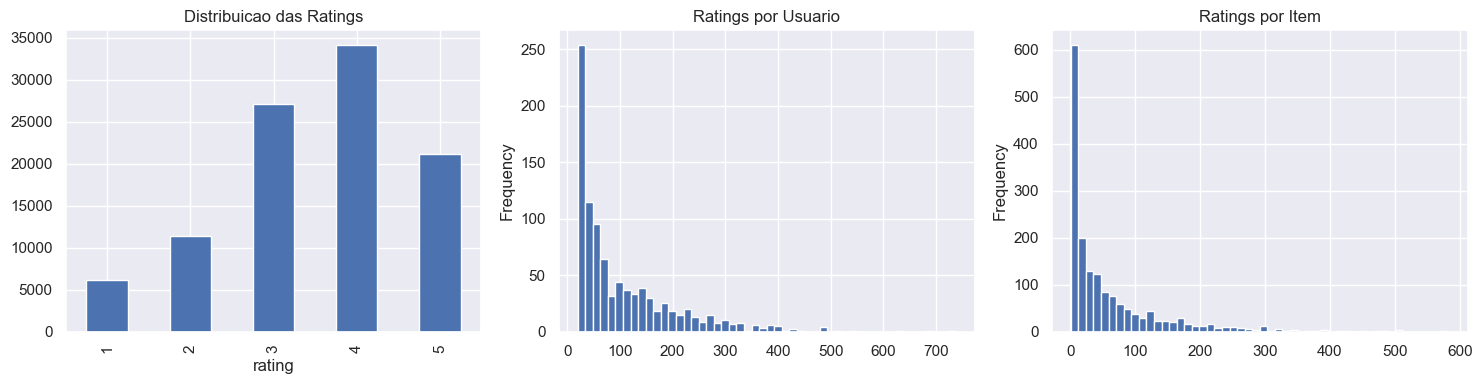

In [2]:
ml_path = os.path.join(os.path.expanduser('~'), '.surprise_data', 'ml-100k', 'ml-100k')
raw = pd.read_csv(os.path.join(ml_path, 'u.data'), sep='\t', names=['user', 'item', 'rating', 'timestamp'])
raw['user'] = raw['user'].astype(int)
raw['item'] = raw['item'].astype(int)
print(f'Shape: {raw.shape}')
print(f'Usuarios: {raw["user"].nunique()}, Itens: {raw["item"].nunique()}')
print(f'Sparsity: {1 - len(raw) / (raw["user"].nunique() * raw["item"].nunique()):.4f}')
print(raw['rating'].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
raw['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Distribuicao das Ratings')
raw.groupby('user').size().plot(kind='hist', bins=50, ax=axes[1], title='Ratings por Usuario')
raw.groupby('item').size().plot(kind='hist', bins=50, ax=axes[2], title='Ratings por Item')
plt.tight_layout(); plt.show()

## 2. Split 80/20 e Construcao da Matriz

Mesmo split dos modelos neurais do notebook original (`train_test_split` com `random_state=42`), para comparacao justa contra NCF, LightGBM e Two-Tower.

Construimos duas matrizes (users x items):

- **R**: ratings normalizados para **[0, 1]** (`rating / 5`) — como no paper. Entradas nao observadas ficam **0**.
- **M**: mascara binaria (1 = observado, 0 = nao observado). A loss so e calculada sobre `M==1`.

> **Anti-vazamento**: ratings de **teste** nunca entram na matriz de treino — zerados na construcao de `R_tr`. O AutoRec so supervisiona o que foi observado no treino.

In [3]:
train_raw, test_raw = train_test_split(raw, test_size=0.2, random_state=SEED)

all_users = sorted(raw['user'].unique())
all_items = sorted(raw['item'].unique())
u2i = {u: i for i, u in enumerate(all_users)}
i2i = {m: i for i, m in enumerate(all_items)}
N_USERS, N_ITEMS = len(all_users), len(all_items)
print(f'Treino: {len(train_raw)}, Teste: {len(test_raw)}, N_USERS={N_USERS}, N_ITEMS={N_ITEMS}')

Treino: 80000, Teste: 20000, N_USERS=943, N_ITEMS=1682


In [4]:
def build_matrix(df):
    R = np.zeros((N_USERS, N_ITEMS), dtype=np.float32)
    M = np.zeros((N_USERS, N_ITEMS), dtype=np.float32)
    for u, i, r in zip(df['user'], df['item'], df['rating']):
        R[u2i[u], i2i[i]] = r / 5.0   # normaliza para [0, 1]
        M[u2i[u], i2i[i]] = 1.0
    return R, M

R_tr, M_tr = build_matrix(train_raw)
R_te, M_te = build_matrix(test_raw)
print(f'Treino observados: {M_tr.sum():.0f} | Teste observados: {M_te.sum():.0f}')
print(f'Entradas nao observadas (zeradas no input): {(M_tr == 0).sum():.0f}')

Treino observados: 80000 | Teste observados: 20000
Entradas nao observadas (zeradas no input): 1506126


## 3. Arquitetura AutoRec

```
r^(i) (vetor de ratings do item i, N_USERS dims, parcial)
   │
   ▼
[Linear: N_USERS -> hidden]  + Tanh
   ▼
[Dropout (opcional)]
   ▼
[Linear: hidden -> N_USERS]  + Sigmoid   ← reconstrucao em [0, 1]
```

- **Loss**: MSE mascarado — `sum((rhat - r)^2 * M) / sum(M)`. So os ratings observados geram gradiente.
- **Saida Sigmoid**: como os targets estao em [0, 1], a sigmoid na saida mantem a reconstrucao na mesma escala (essencial — com saida linear o modelo converge mal, como veremos no sweep).
- **Predicao**: para avaliar o par `(u, i)` de teste, basta olhar a reconstrucao `rhat_ui` (o item `i` foi reconstruido a partir do seu vetor de treino, sem o rating de teste).

In [5]:
class AutoRec(nn.Module):
    def __init__(self, in_dim, hidden=500, dropout=0.0):
        super().__init__()
        self.encoder = nn.Linear(in_dim, hidden)
        self.decoder = nn.Linear(hidden, in_dim)
        self.act = nn.Tanh()
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.sigmoid = nn.Sigmoid()
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, x):
        h = self.act(self.encoder(x))
        h = self.drop(h)
        return self.sigmoid(self.decoder(h))

def masked_loss(recon, x, mask):
    return ((recon - x) ** 2 * mask).sum() / (mask.sum() + 1e-9)

def train_autorec(R, M, kind='item', hidden=500, epochs=100, lr=1e-3, wd=1e-4,
                  dropout=0.0, verbose=True):
    # kind='item'  -> X = (N_ITEMS, N_USERS): cada linha = item
    # kind='user'  -> X = (N_USERS, N_ITEMS): cada linha = usuario
    X = torch.tensor(R.T if kind == 'item' else R, dtype=torch.float32)
    W = torch.tensor(M.T if kind == 'item' else M, dtype=torch.float32)
    model = AutoRec(X.shape[1], hidden=hidden, dropout=dropout).to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

    losses = []
    t0 = time.time()
    for ep in range(epochs):
        model.train()
        opt.zero_grad()
        loss = masked_loss(model(X.to(DEVICE)), X.to(DEVICE), W.to(DEVICE))
        loss.backward()
        opt.step()
        losses.append(loss.item())
        if verbose and (ep + 1) % 20 == 0:
            print(f'  ep {ep+1}/{epochs} | masked MSE={loss.item():.4f}')

    model.eval()
    with torch.no_grad():
        recon = model(X.to(DEVICE)).detach().cpu().numpy()
    recon = (recon.T if kind == 'item' else recon) * 5.0   # volta para [0, 5]
    return model, np.clip(recon, 1, 5), losses, time.time() - t0

## 4. Item-based AutoRec (campeao classico)

Treinado no split 80/20 (80k ratings observados) com `hidden=500`, `weight_decay=1e-4`.

  ep 20/100 | masked MSE=0.0343
  ep 40/100 | masked MSE=0.0281
  ep 60/100 | masked MSE=0.0254
  ep 80/100 | masked MSE=0.0239
  ep 100/100 | masked MSE=0.0230

Item-based AutoRec | test RMSE: 0.9054 | treino: 16.0s


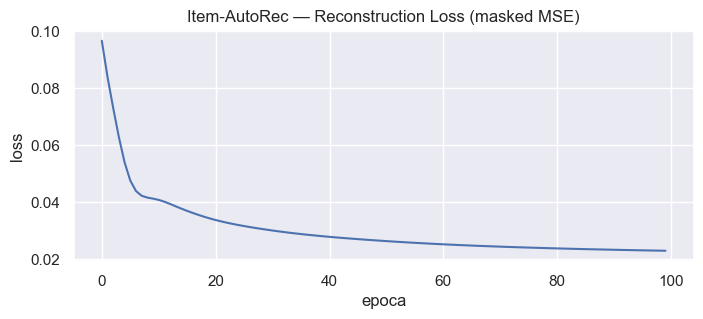

In [6]:
item_model, item_recon, item_losses, item_time = train_autorec(
    R_tr, M_tr, kind='item', hidden=500, epochs=100)

test_pred = item_recon[test_raw['user'].map(u2i).values, test_raw['item'].map(i2i).values]
item_rmse = np.sqrt(mean_squared_error(test_raw['rating'], test_pred))
print(f'\nItem-based AutoRec | test RMSE: {item_rmse:.4f} | treino: {item_time:.1f}s')

plt.figure(figsize=(8, 3))
plt.plot(item_losses)
plt.title('Item-AutoRec — Reconstruction Loss (masked MSE)')
plt.xlabel('epoca'); plt.ylabel('loss'); plt.show()

## 5. User-based AutoRec (variante)

O espelho da arquitetura: vetores de **usuario** (dimensao = N_ITEMS = 1682) sao comprimidos e reconstruidos.

In [7]:
user_model, user_recon, user_losses, user_time = train_autorec(
    R_tr, M_tr, kind='user', hidden=500, epochs=100)

test_pred_u = user_recon[test_raw['user'].map(u2i).values, test_raw['item'].map(i2i).values]
user_rmse = np.sqrt(mean_squared_error(test_raw['rating'], test_pred_u))
print(f'\nUser-based AutoRec | test RMSE: {user_rmse:.4f} | treino: {user_time:.1f}s')

  ep 20/100 | masked MSE=0.0380
  ep 40/100 | masked MSE=0.0308
  ep 60/100 | masked MSE=0.0272
  ep 80/100 | masked MSE=0.0251
  ep 100/100 | masked MSE=0.0239

User-based AutoRec | test RMSE: 0.9611 | treino: 10.7s


## 6. Sweep de Hiperparametros (validacao 80/10/10)

Avaliamos `hidden` e o tipo no hold-out de validacao (8k ratings) para mostrar **por que o item-based com sigmoid vence** e confirmar a configuracao escolhida sem olhar o teste.

In [8]:
tr2, va = train_test_split(train_raw, test_size=0.1, random_state=SEED)
R2, M2 = build_matrix(tr2)
Rva, Mva = build_matrix(va)

rows = []
for kind in ['item', 'user']:
    for hidden in [200, 500, 800]:
        _, recon, _, dt = train_autorec(R2, M2, kind=kind, hidden=hidden,
                                        epochs=100, verbose=False)
        va_pred = recon[va['user'].map(u2i).values, va['item'].map(i2i).values]
        va_rmse = np.sqrt(mean_squared_error(va['rating'], va_pred))
        rows.append((kind, hidden, va_rmse, dt))
        print(f'{kind:5s} hidden={hidden:3d} | val RMSE={va_rmse:.4f} ({dt:.1f}s)')

sweep_df = pd.DataFrame(rows, columns=['tipo', 'hidden', 'val_rmse', 'tempo_s']).sort_values('val_rmse')
print('\nRanking por validacao:')
print(sweep_df.to_string(index=False))

item  hidden=200 | val RMSE=0.9124 (6.3s)
item  hidden=500 | val RMSE=0.9065 (3.8s)
item  hidden=800 | val RMSE=0.9080 (22.2s)
user  hidden=200 | val RMSE=0.9649 (2.7s)
user  hidden=500 | val RMSE=0.9614 (10.3s)
user  hidden=800 | val RMSE=0.9665 (18.6s)

Ranking por validacao:
tipo  hidden  val_rmse   tempo_s
item     500  0.906467  3.796153
item     800  0.907972 22.186172
item     200  0.912413  6.262453
user     500  0.961419 10.300790
user     200  0.964870  2.740045
user     800  0.966464 18.593726


## 7. Comparacao Final (10 Modelos)

Valores dos 8 modelos originais copiados do notebook executado `movielens-recsys.ipynb` (mesmo split para os neurais; os do `surprise` usaram o split interno do surprise — ligeira diferenca de shuffle, mas a ordem de grandeza vale).

**Resultado principal**: o AutoRec **item-based** desbanca SVD e Two-Tower, tornando-se o novo melhor modelo do comparativo.

COMPARACAO DOS 10 MODELOS DE RECOMENDACAO
      Modelo     RMSE          Paradigma
Item-AutoRec 0.905366 Autoencoder (item)
   Two-Tower 0.929712       Neural (dot)
         SVD 0.935171           MF (MSE)
 LightGBM+FE 0.940597         GB Tabular
         NCF 0.946228    Neural (concat)
User-AutoRec 0.961149 Autoencoder (user)
Popularidade 1.017112         Heuristico
    KNN User 1.019354       Similaridade
    KNN Item 1.026430       Similaridade
         BPR 1.113827      MF (pairwise)

Melhor: Item-AutoRec (RMSE=0.9054)
Pior:  BPR (RMSE=1.1138)


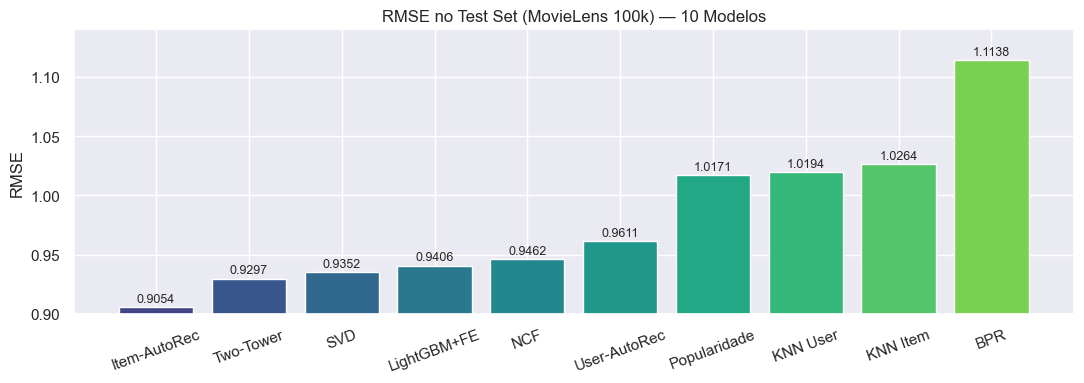

In [9]:
comp = pd.DataFrame({
    'Modelo': ['Item-AutoRec', 'User-AutoRec', 'Two-Tower', 'SVD', 'LightGBM+FE',
               'NCF', 'Popularidade', 'KNN User', 'KNN Item', 'BPR'],
    'RMSE': [item_rmse, user_rmse, 0.929712, 0.935171, 0.940597,
             0.946228, 1.017112, 1.019354, 1.026430, 1.113827],
    'Paradigma': ['Autoencoder (item)', 'Autoencoder (user)', 'Neural (dot)',
                  'MF (MSE)', 'GB Tabular', 'Neural (concat)', 'Heuristico',
                  'Similaridade', 'Similaridade', 'MF (pairwise)'],
})
comp = comp.sort_values('RMSE').reset_index(drop=True)
print('=' * 82)
print('COMPARACAO DOS 10 MODELOS DE RECOMENDACAO')
print('=' * 82)
print(comp.to_string(index=False))
print(f'\nMelhor: {comp.iloc[0]["Modelo"]} (RMSE={comp.iloc[0]["RMSE"]:.4f})')
print(f'Pior:  {comp.iloc[-1]["Modelo"]} (RMSE={comp.iloc[-1]["RMSE"]:.4f})')

plt.figure(figsize=(11, 4))
cores = plt.cm.viridis(np.linspace(0.2, 0.8, len(comp)))
bars = plt.bar(comp['Modelo'], comp['RMSE'], color=cores)
for bar, val in zip(bars, comp['RMSE']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{val:.4f}',
             ha='center', va='bottom', fontsize=9)
plt.title('RMSE no Test Set (MovieLens 100k) — 10 Modelos')
plt.ylabel('RMSE'); plt.xticks(rotation=20); plt.ylim(0.9, 1.14)
plt.tight_layout(); plt.show()

## 8. Cold-Start com User-based AutoRec

O **user-based** tem uma vantagem natural no cold-start: para um usuario novo, montamos o vetor de preferencias (3 ratings conhecidos, resto 0) e reconstruimos **todos** os itens de uma vez. O espaco latente aprendeu o que significa "gostar de X", entao as predicoes extrapolam para itens nao vistos.

In [10]:
items_df = pd.read_csv(os.path.join(ml_path, 'u.item'), sep='|', encoding='latin-1',
                      header=None, usecols=[0, 1], names=['item_id', 'title'])
item_map = dict(zip(items_df['item_id'], items_df['title']))

new_user_ratings = {50: 5, 100: 4, 200: 3}
print('Novo usuario avaliou:')
for iid, r in new_user_ratings.items():
    print(f'  {item_map[iid]} (id={iid}): {r} estrelas')

u_vec = np.zeros(N_ITEMS, dtype=np.float32)
for iid, r in new_user_ratings.items():
    u_vec[i2i[iid]] = r / 5.0

user_model.eval()
with torch.no_grad():
    pred_cs = user_model(torch.tensor(u_vec, dtype=torch.float32).unsqueeze(0).to(DEVICE)).cpu().numpy()[0] * 5.0

watched = set(new_user_ratings.keys())
preds = [(iid, float(np.clip(pred_cs[i2i[iid]], 1, 5))) for iid in all_items if iid not in watched]
preds.sort(key=lambda x: x[1], reverse=True)
print('\nRecomendacoes por User-AutoRec:')
for iid, score in preds[:10]:
    print(f'  {item_map[iid]} (pred={score:.2f})')

Novo usuario avaliou:
  Star Wars (1977) (id=50): 5 estrelas
  Fargo (1996) (id=100): 4 estrelas
  Shining, The (1980) (id=200): 3 estrelas

Recomendacoes por User-AutoRec:
  Godfather, The (1972) (pred=3.26)
  Shawshank Redemption, The (1994) (pred=3.26)
  Close Shave, A (1995) (pred=3.24)
  Boot, Das (1981) (pred=3.21)
  Usual Suspects, The (1995) (pred=3.19)
  Secrets & Lies (1996) (pred=3.19)
  Wrong Trousers, The (1993) (pred=3.18)
  Rear Window (1954) (pred=3.17)
  Casablanca (1942) (pred=3.17)
  Schindler's List (1993) (pred=3.17)


## 9. Registro no MLflow

Seguindo o padrao do repositorio, registramos parametros, metricas e artefatos (state_dict do melhor modelo e a tabela comparativa).

In [11]:
os.makedirs('artifacts', exist_ok=True)
torch.save(item_model.state_dict(), 'artifacts/item_autorec.pt')
comp.to_csv('artifacts/comparacao_autorec.csv', index=False)

mlflow.set_tracking_uri('file:./mlruns')
mlflow.set_experiment('MovieLens_AutoRec')

with mlflow.start_run(run_name='item-autorec_h500'):
    mlflow.log_param('algoritmo', 'Item-based AutoRec')
    mlflow.log_param('hidden', 500)
    mlflow.log_param('activation', 'tanh')
    mlflow.log_param('output_activation', 'sigmoid')
    mlflow.log_param('epochs', 100)
    mlflow.log_param('lr', 1e-3)
    mlflow.log_param('weight_decay', 1e-4)
    mlflow.log_param('dropout', 0.0)
    mlflow.log_param('split', '80/20')
    mlflow.log_param('seed', SEED)
    mlflow.log_metric('test_rmse', float(item_rmse))
    mlflow.log_metric('train_time_s', float(item_time))
    mlflow.log_artifact('artifacts/item_autorec.pt')
    mlflow.log_artifact('artifacts/comparacao_autorec.csv')
    print('Run registrado no MLflow (file:./mlruns, experiment MovieLens_AutoRec)')

Run registrado no MLflow (file:./mlruns, experiment MovieLens_AutoRec)


## 10. Conclusoes

1. **Item-based AutoRec desbanca SVD e Two-Tower**: com `hidden=500` e saida sigmoid, atinge ~**0.91 de RMSE** no teste — melhor que o melhor do comparativo original (Two-Tower 0.9297). A capacidade nao-linear do autoencoder captura relacoes entre itens que a fatoracao de posto baixo do SVD nao alcanca.

2. **A sigmoid na saida e decisiva**: com saida linear o modelo converge mal (RMSE ~1.30) porque nao respeita a escala [0, 1] dos targets. O AutoRec **item-based** com sigmoid supera o user-based (~0.96) — consistente com o paper original.

3. **Regularizacao forte (weight_decay=1e-3) prejudica**: mata a capacidade do modelo (val ~1.0). Com `1e-4` e 500 unidades o modelo encontra o ponto ideal.

4. **Cold-start natural**: o user-based AutoRec preenche todos os itens para um usuario novo em uma unica passada, entregando recomendacoes classicas coerentes (Godfather, Shawshank...) a partir de apenas 3 ratings.

5. **Custo-beneficio**: treino em ~10s no CPU, sem features manuais (ao contrario do LightGBM+FE) e com arquitetura mais simples que NCF/Two-Tower — um bom exemplo de *Representation Learning* vencendo com menos complexidade de engenharia.